In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [2]:
class QuadState(TypedDict):
    a:int
    b:int
    c:int 
    equation: str
    discriminant: str
    result: str

In [36]:
from typing import Literal


def calculate_equation(state: QuadState):
    equation = state['a']*(2*state['b'])*state['c']
    return {'equation':equation}

def  calculate_discriminant(state: QuadState):
    discriminant = state['b']**2 -(4 * state['a']*state['c'])
    return {'discriminant':discriminant}

def real_roots(state: QuadState):
    root1 = -state['b'] + (state['discriminant']**0.5)/(2*state['a'])
    root2 = -state['b'] - (state['discriminant']**0.5)/(2*state['a'])

    result = f'The roots are {root1} & {root2}'

    return {'result': result}

def repeated_roots(state:QuadState):
        root = -(state['b'])/(2*state['a'])
        result = f'Only repeated root is {root}'
        return {'result':result}


def no_real_roots(state:QuadState):
        result = f'No real roots'
        return {'result':result}        

def check_condition(state:QuadState):
  if state['discriminant']>0:
    return 'real_roots'
  elif state['discriminant'] == 0:
    return 'repeated_roots'
  else:
   return 'no_real_roots'


In [37]:
graph = StateGraph(QuadState)
graph.add_node('calculate_equation',calculate_equation)
graph.add_node('calculate_discriminant',calculate_discriminant)
graph.add_node('real_roots',real_roots)
graph.add_node('repeated_roots',repeated_roots)
graph.add_node('no_real_roots',no_real_roots)


graph.add_edge(START, 'calculate_equation')
graph.add_edge('calculate_equation', 'calculate_discriminant')
graph.add_conditional_edges('calculate_discriminant',check_condition)
graph.add_edge('calculate_discriminant', END)




workflow = graph.compile()

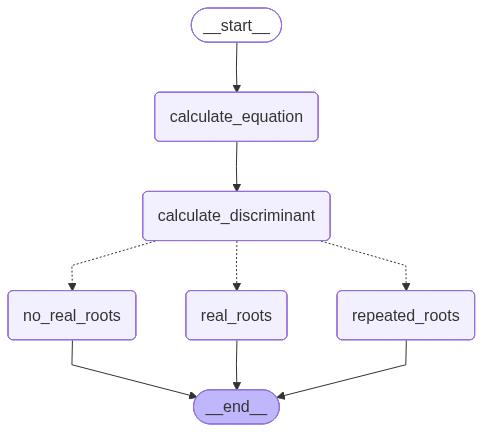

In [35]:
initial_state = {
    'a':4,
    'b':-5,
    'c':-4
    
}

workflow.invoke(initial_state)
workflow
